In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!pip install -q \
    "diffusers==0.35.2" \
    "transformers==4.56.2" \
    "accelerate>=1.10.0,<2.0.0" \
    "safetensors>=0.6.0,<1.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 44.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 93.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.1 MB/s eta 0:00:00


In [3]:
import torch
from diffusers import StableDiffusionXLPipeline

MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"

pipe = StableDiffusionXLPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
)

pipe = pipe.to("cuda")

pipe.enable_attention_slicing()

print("SDXL loaded successfully.")

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/737 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

scheduler_config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

vae_1_0/diffusion_pytorch_model.fp16.saf(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


SDXL loaded successfully.


  0%|          | 0/30 [00:00<?, ?it/s]

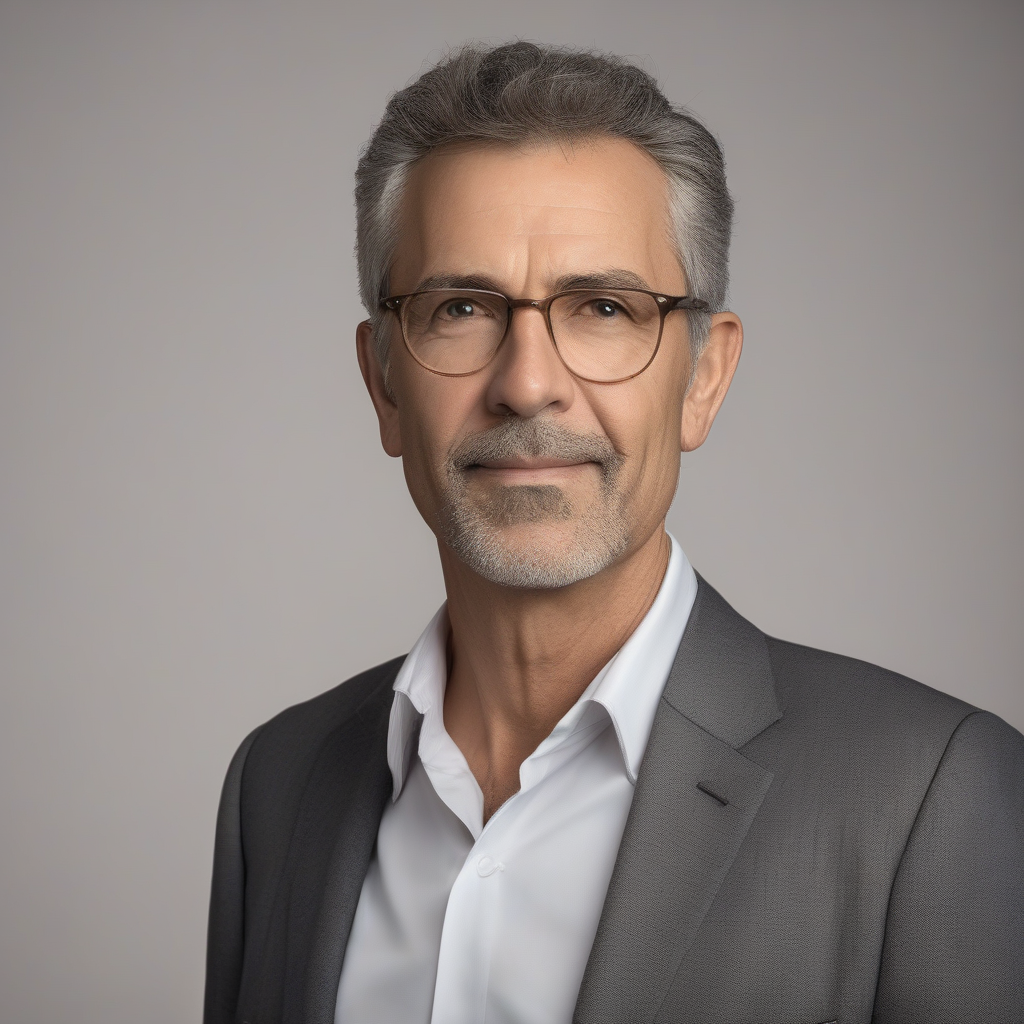

In [4]:
prompt = """
A professional studio portrait of a fictional adult person,
front-facing, natural expression, formal business attire,
neutral professional background, realistic photography,
soft studio lighting, high detail
"""

negative_prompt = """
blurry, distorted face, deformed, extra fingers,
extra limbs, low quality, duplicate person,
text, watermark, logo
"""

import torch

generator = torch.Generator(device="cuda").manual_seed(42)

result = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    width=1024,
    height=1024,
    num_inference_steps=30,
    guidance_scale=7.0,
    generator=generator,
)

image = result.images[0]

display(image)

In [5]:
from pathlib import Path

output_dir = Path("/kaggle/working/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "avatar_test.png"

image.save(output_path)

print(f"Saved: {output_path}")

Saved: /kaggle/working/outputs/avatar_test.png
